In [105]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [106]:
from tobii_pytracker.analyze.data_loader import DataLoader
from tobii_pytracker.configs.custom_config import CustomConfig

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

from tobii_pytracker.analyze.models import (
    HeatmapAnalyzer,
    FocusMapAnalyzer,
    FixationAnalyzer,
    SaccadeAnalyzer,
    EntropyAnalyzer,
    ClusterAnalyzer,
    ConceptAnalyzer,
    ScanpathsAnalyzer,
    VoiceTranscription,
    BBoxAttentionAnalyzer
)


config = CustomConfig('../configs/config.yaml')
loader = DataLoader(config, root='../')

▶ Global heatmap statistics


,avg_gaze_x,avg_gaze_y,gaze_count
0,-45.468806,11.640034,1110


▶ Per-set statistics


,set_name,avg_gaze_x,avg_gaze_y,gaze_count
0,20260719_172643,-45.468806,11.640034,1110


▶ Per-slide statistics


,set_name,slide_index,avg_gaze_x,avg_gaze_y,gaze_count
0,20260719_172643,0,-81.839638,-6.429893,95
1,20260719_172643,1,-63.485125,59.674795,99
2,20260719_172643,2,-24.554975,45.034951,95
3,20260719_172643,3,-17.520049,-23.671476,98
4,20260719_172643,4,-55.000690,6.382891,198


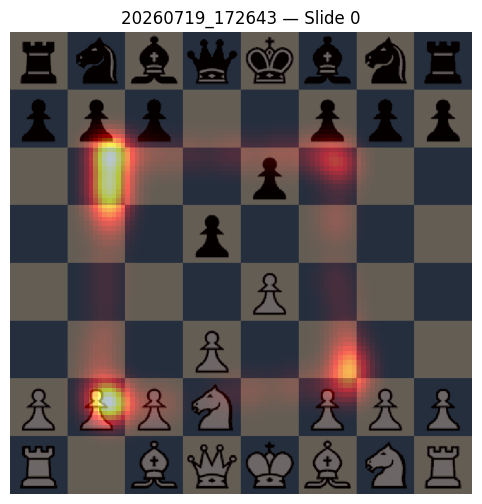

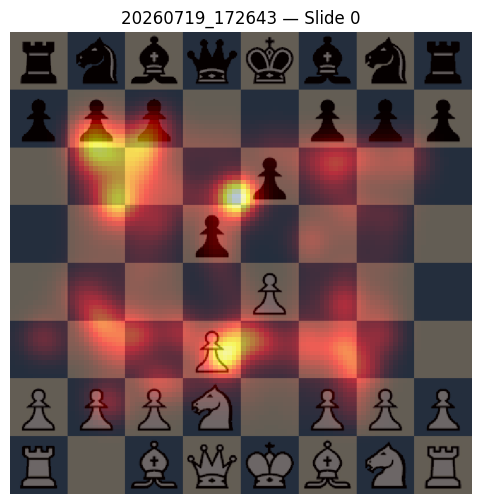

In [107]:
# Assuming you already have the data
background_data = pd.concat(loader.get_all_data(flatten=True).values(), ignore_index=True)
output_dir = Path("./analysis_outputs")

analyzer = HeatmapAnalyzer(output_folder=output_dir)

# --- Global ---
print("▶ Global heatmap statistics")
global_stats = analyzer.analyze(background_data, per="global")
display(global_stats)

# --- Set-level ---
print("▶ Per-set statistics")
set_stats = analyzer.analyze(background_data, per="set")
display(set_stats.head())

# --- Slide-level ---
print("▶ Per-slide statistics")
slide_stats = analyzer.analyze(background_data, per="slide")
display(slide_stats.head())

# --- Plot heatmap for one image ---
example_slide = background_data.iloc[0]
subset = background_data[
    (background_data["set_name"] == example_slide["set_name"]) &
    (background_data["slide_index"] == example_slide["slide_index"])
]
screenshot_path = Path(loader.root) / example_slide["screenshot_file"]

analyzer.plot_analysis(
    background_data=subset,
    screenshot_path=screenshot_path,
    title=f"{example_slide['set_name']} — Slide {example_slide['slide_index']}",
)


analyzer.plot_analysis(
    background_data=background_data,
    screenshot_path=screenshot_path,
    title=f"{example_slide['set_name']} — Slide {example_slide['slide_index']}",
)


▶ Global focus map statistics


,avg_gaze_x,avg_gaze_y,gaze_count
0,-45.468806,11.640034,1110


▶ Per-set statistics


,set_name,avg_gaze_x,avg_gaze_y,gaze_count
0,20260719_172643,-45.468806,11.640034,1110


▶ Per-slide statistics


,set_name,slide_index,avg_gaze_x,avg_gaze_y,gaze_count
0,20260719_172643,0,-81.839638,-6.429893,95
1,20260719_172643,1,-63.485125,59.674795,99
2,20260719_172643,2,-24.554975,45.034951,95
3,20260719_172643,3,-17.520049,-23.671476,98
4,20260719_172643,4,-55.000690,6.382891,198


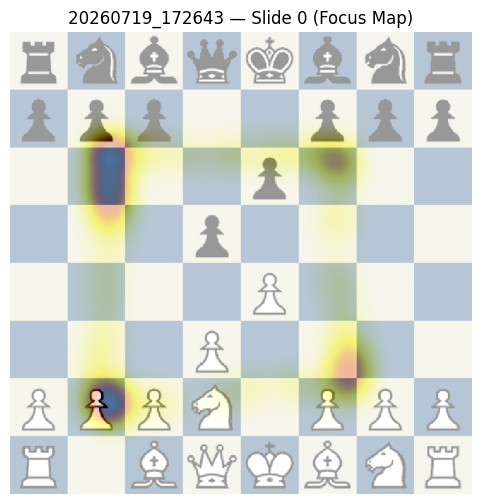

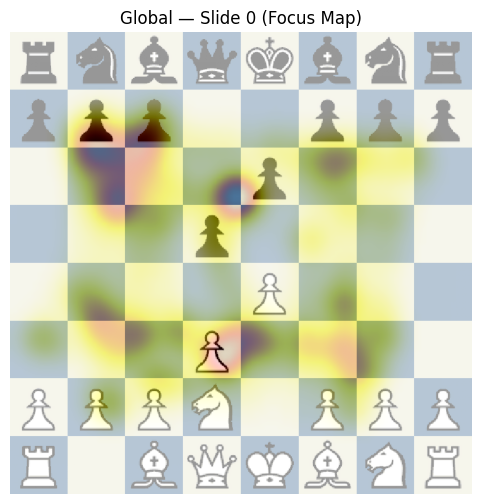

In [108]:
# --- Prepare background data ---
background_data = pd.concat(loader.get_all_data(flatten=True).values(), ignore_index=True)
output_dir = Path("./analysis_outputs")

analyzer = FocusMapAnalyzer(output_folder=output_dir)

# --- Global ---
print("▶ Global focus map statistics")
global_stats = analyzer.analyze(background_data, per="global")
display(global_stats)

# --- Set-level ---
print("▶ Per-set statistics")
set_stats = analyzer.analyze(background_data, per="set")
display(set_stats.head())

# --- Slide-level ---
print("▶ Per-slide statistics")
slide_stats = analyzer.analyze(background_data, per="slide")
display(slide_stats.head())

# ============================================================
# 🖼 Plot focus map for one example slide
# ============================================================

example_slide = background_data.iloc[0]
subset = background_data[
    (background_data["set_name"] == example_slide["set_name"]) &
    (background_data["slide_index"] == example_slide["slide_index"])
]
screenshot_path = Path(loader.root) / example_slide["screenshot_file"]

# --- Focus map for single slide (individual subject) ---
analyzer.plot_analysis(
    background_data=subset,
    screenshot_path=screenshot_path,
    title=f"{example_slide['set_name']} — Slide {example_slide['slide_index']} (Focus Map)",
)

# --- Focus map using all gaze data for this slide (across subjects) ---
analyzer.plot_analysis(
    background_data=background_data,
    screenshot_path=screenshot_path,
    title=f"Global — Slide {example_slide['slide_index']} (Focus Map)",
)

▶ Detecting saccades...


,set_name,slide_index,start_time,end_time,duration,x_start,y_start,x_end,y_end,amplitude,peak_velocity,mean_velocity,mean_acceleration
0,20260719_172643,0,41.428083,41.706833,0.299375,-206.988281,172.707031,159.058594,165.597656,366.115908,2830.053439,1276.173306,22677.359072
1,20260719_172643,0,41.748386,41.944800,0.217223,159.058594,156.292969,175.519531,-161.136719,317.856208,3423.291816,1494.433451,55618.514561
2,20260719_172643,0,41.986056,42.317853,0.352387,176.226562,-165.390625,-212.410156,-229.050781,393.816092,4456.730513,1345.935051,54840.973599
3,20260719_172643,0,42.483984,42.483984,0.020751,-218.300781,-223.597656,-219.816406,-222.394531,1.935104,93.254484,93.254484,2578.931052
4,20260719_172643,0,42.535842,42.784466,0.258984,-223.851562,-217.675781,-214.617188,93.800781,311.613419,2772.187857,1176.148029,25956.380414


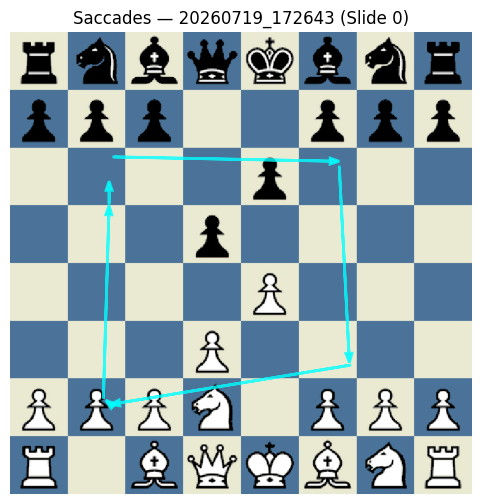

In [109]:
background_data = pd.concat(loader.get_all_data(flatten=True).values(), ignore_index=True)
output_dir = Path("./analysis_outputs")

saccade_analyzer = SaccadeAnalyzer(
    output_folder=output_dir,
    method="ivt",               # "ivt" (velocity-based) or "acceleration"
    velocity_threshold=120.0,   # pixels/sec
    acceleration_threshold=6000.0,  # pixels/sec^2
    min_duration=0.015,         # seconds
)

print("▶ Detecting saccades...")
saccades = saccade_analyzer.analyze(background_data)
display(saccades.head())

example_slide = background_data.iloc[0]
screenshot_path = Path(loader.root) / example_slide["screenshot_file"]

saccade_analyzer.plot_analysis(
    saccades=saccades,
    screenshot_path=screenshot_path,
    set_name=example_slide["set_name"],
    slide_index=int(example_slide["slide_index"]) ,
    title=f"Saccades — {example_slide['set_name']} (Slide {example_slide['slide_index']})",
)

▶ Detecting fixations...


,fix_start,fix_end,duration,x_mean,y_mean,dispersion,set_name,slide_index
0,41.159898,41.469379,0.309481,-202.416748,172.752930,89.453125,20260719_172643,0
1,41.624193,41.769069,0.144876,154.327148,153.500977,106.449219,20260719_172643,0
2,41.882839,42.089563,0.206724,176.714844,-173.255682,60.183594,20260719_172643,0
3,42.224466,42.421597,0.197131,-204.562500,-228.355824,61.156250,20260719_172643,0
4,42.442351,42.577282,0.134931,-221.956543,-210.349121,66.515625,20260719_172643,0


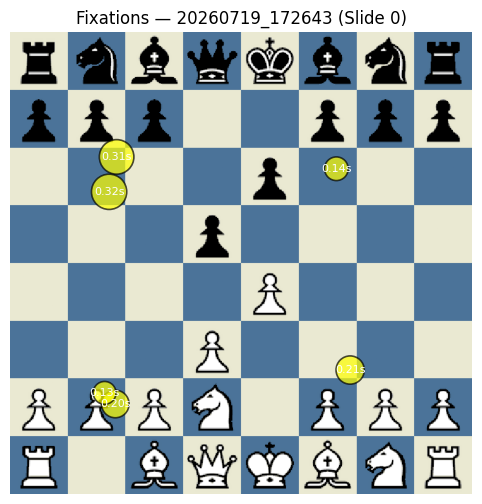

In [110]:
background_data = pd.concat(loader.get_all_data(flatten=True).values(), ignore_index=True)
output_dir = Path("./analysis_outputs")

fixation_analyzer = FixationAnalyzer(
    output_folder=output_dir,
    method="dispersion",           # or "velocity"
    dispersion_threshold=60.0,     # pixels
    min_duration=0.08,             # seconds
)

print("▶ Detecting fixations...")
fixations = fixation_analyzer.analyze(background_data)
display(fixations.head())

example_slide = background_data.iloc[0]
screenshot_path = Path(loader.root) / example_slide["screenshot_file"]

fixation_analyzer.plot_analysis(
    fixations=fixations,
    screenshot_path=screenshot_path,
    set_name=example_slide["set_name"],
    slide_index=int(example_slide["slide_index"]),
    title=f"Fixations — {example_slide['set_name']} (Slide {example_slide['slide_index']})",
)

▶ Performing gaze clustering...


,set_name,slide_index,screenshot_file,input_data,classification,user_classification,model_prediction,voice_file,voice_start_timestamp,event_type,...,gaze_x_left,gaze_y_left,gaze_x_right,gaze_y_right,pupil_left,pupil_right,avg_gaze_x,avg_gaze_y,avg_pupil_size,cluster
0,20260719_172643,0,output/20260719_172643/frame_05_delay-1s.gif,datasets/chess/good/frame_05_delay-1s.gif,good,good,None,NaN,NaN,MonocularEyeSampleEventNT,...,-213.265625,172.707031,None,None,5,0,-213.265625,172.707031,2.5,0
1,20260719_172643,0,output/20260719_172643/frame_05_delay-1s.gif,datasets/chess/good/frame_05_delay-1s.gif,good,good,None,NaN,NaN,MonocularEyeSampleEventNT,...,-213.265625,172.707031,None,None,5,0,-213.265625,172.707031,2.5,0
2,20260719_172643,0,output/20260719_172643/frame_05_delay-1s.gif,datasets/chess/good/frame_05_delay-1s.gif,good,good,None,NaN,NaN,MonocularEyeSampleEventNT,...,-213.265625,172.707031,None,None,5,0,-213.265625,172.707031,2.5,0
3,20260719_172643,0,output/20260719_172643/frame_05_delay-1s.gif,datasets/chess/good/frame_05_delay-1s.gif,good,good,None,NaN,NaN,MonocularEyeSampleEventNT,...,-213.265625,172.707031,None,None,5,0,-213.265625,172.707031,2.5,0
4,20260719_172643,0,output/20260719_172643/frame_05_delay-1s.gif,datasets/chess/good/frame_05_delay-1s.gif,good,good,None,NaN,NaN,MonocularEyeSampleEventNT,...,-213.265625,172.707031,None,None,5,0,-213.265625,172.707031,2.5,0


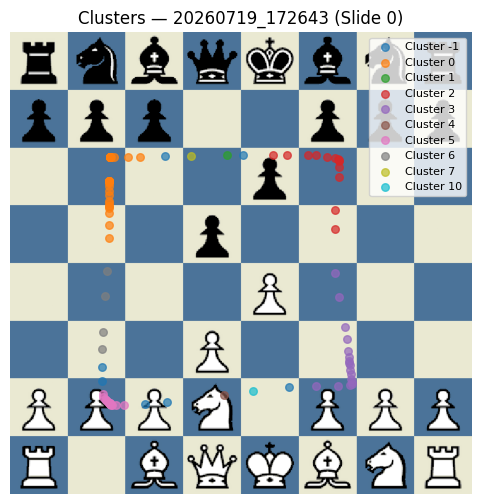

In [111]:
# ==============================================
# 👁️ Cluster Analyzer Demo
# ==============================================
from pathlib import Path
import pandas as pd

background_data= pd.concat(loader.get_all_data(flatten=True).values(), ignore_index=True)
output_dir = Path("./analysis_outputs")

# Instantiate analyzer (DBSCAN by default)
cluster_analyzer = ClusterAnalyzer(
    output_folder=output_dir,
    eps=20,              # pixel distance for clustering
    min_samples=3,        # minimum points per cluster
)

print("▶ Performing gaze clustering...")
clustered_data = cluster_analyzer.analyze(background_data)
display(clustered_data.head())

# --- Visualization for one slide ---
example_slide = background_data.iloc[0]
screenshot_path = Path(loader.root) / example_slide["screenshot_file"]

cluster_analyzer.plot_analysis(
    background_data=clustered_data,
    screenshot_path=screenshot_path,
    set_name=example_slide["set_name"],
    slide_index=int(example_slide["slide_index"]),
    title=f"Clusters — {example_slide['set_name']} (Slide {example_slide['slide_index']})",
)

▶ Slide-level entropy


,entropy,convex_hull_area,num_points,set_name,slide_index
0,5.619092,152140.285446,95,20260719_172643,0
1,5.666961,116267.813538,99,20260719_172643,1
2,5.973318,165056.499466,95,20260719_172643,2
3,5.757019,141810.693535,98,20260719_172643,3
4,5.465988,33057.790344,198,20260719_172643,4


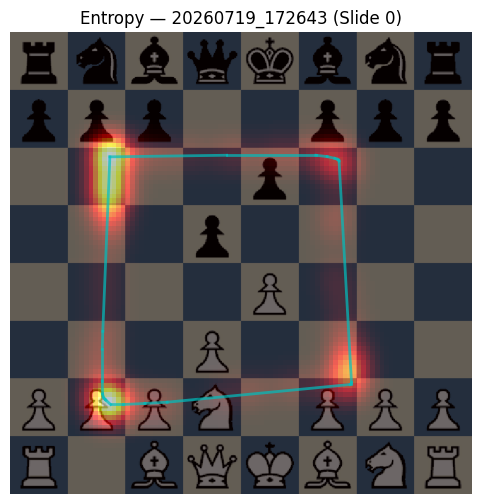

In [112]:
# ==============================================
# 🧠 Entropy Analyzer Demo
# ==============================================
background_data = pd.concat(loader.get_all_data(flatten=True).values(), ignore_index=True)
output_dir = Path("./analysis_outputs")

entropy_analyzer = EntropyAnalyzer(output_folder=output_dir)

print("▶ Slide-level entropy")
entropy_results = entropy_analyzer.analyze(background_data, per="slide", bins=100, use_convex_hull=True)
display(entropy_results.head())

# --- Visualization for one example slide ---
example_slide = background_data.iloc[0]
subset = background_data[
    (background_data["set_name"] == example_slide["set_name"]) &
    (background_data["slide_index"] == example_slide["slide_index"])
]
screenshot_path = Path(loader.root) / example_slide["screenshot_file"]

entropy_analyzer.plot_analysis(
    background_data=subset,
    screenshot_path=screenshot_path,
    title=f"Entropy — {example_slide['set_name']} (Slide {example_slide['slide_index']})",
)


▶ Loading data for bbox analysis
Experiment sets used: ['20260719_172643']
Raw image rows: 10
Gaze samples: 1110


,set_name,screenshot_file,input_data,classification,user_classification,gaze_data,objects_bboxes,voice_file,voice_start_timestamp,slide_index
10,20260719_172643,output/20260719_172643/frame_05_delay-1s.gif,datasets/chess/good/frame_05_delay-1s.gif,good,good,"[{'event_type': 'MonocularEyeSampleEventNT', '...","{'image_bboxes': [{'class': 'superpixel', 'con...",NaN,NaN,0
11,20260719_172643,output/20260719_172643/frame_60_delay-1s.gif,datasets/chess/bad/frame_60_delay-1s.gif,bad,good,"[{'event_type': 'MonocularEyeSampleEventNT', '...","{'image_bboxes': [{'class': 'superpixel', 'con...",NaN,NaN,1
12,20260719_172643,output/20260719_172643/frame_23_delay-1s.gif,datasets/chess/good/frame_23_delay-1s.gif,good,bad,"[{'event_type': 'MonocularEyeSampleEventNT', '...","{'image_bboxes': [{'class': 'superpixel', 'con...",NaN,NaN,2
13,20260719_172643,output/20260719_172643/frame_38_delay-1s.gif,datasets/chess/good/frame_38_delay-1s.gif,good,bad,"[{'event_type': 'MonocularEyeSampleEventNT', '...","{'image_bboxes': [{'class': 'superpixel', 'con...",NaN,NaN,3
14,20260719_172643,output/20260719_172643/frame_64_delay-3s.gif,datasets/chess/bad/frame_64_delay-3s.gif,bad,bad,"[{'event_type': 'MonocularEyeSampleEventNT', '...","{'image_bboxes': [{'class': 'superpixel', 'con...",NaN,NaN,4


,set_name,slide_index,screenshot_file,input_data,classification,user_classification,model_prediction,voice_file,voice_start_timestamp,event_type,...,system_time,gaze_x_left,gaze_y_left,gaze_x_right,gaze_y_right,pupil_left,pupil_right,avg_gaze_x,avg_gaze_y,avg_pupil_size
0,20260719_172643,0,output/20260719_172643/frame_05_delay-1s.gif,datasets/chess/good/frame_05_delay-1s.gif,good,good,None,NaN,NaN,MonocularEyeSampleEventNT,...,41.159898,-213.265625,172.707031,None,None,5,0,-213.265625,172.707031,2.5
1,20260719_172643,0,output/20260719_172643/frame_05_delay-1s.gif,datasets/chess/good/frame_05_delay-1s.gif,good,good,None,NaN,NaN,MonocularEyeSampleEventNT,...,41.180537,-213.265625,172.707031,None,None,5,0,-213.265625,172.707031,2.5
2,20260719_172643,0,output/20260719_172643/frame_05_delay-1s.gif,datasets/chess/good/frame_05_delay-1s.gif,good,good,None,NaN,NaN,MonocularEyeSampleEventNT,...,41.201132,-213.265625,172.707031,None,None,5,0,-213.265625,172.707031,2.5
3,20260719_172643,0,output/20260719_172643/frame_05_delay-1s.gif,datasets/chess/good/frame_05_delay-1s.gif,good,good,None,NaN,NaN,MonocularEyeSampleEventNT,...,41.221779,-213.265625,172.707031,None,None,5,0,-213.265625,172.707031,2.5
4,20260719_172643,0,output/20260719_172643/frame_05_delay-1s.gif,datasets/chess/good/frame_05_delay-1s.gif,good,good,None,NaN,NaN,MonocularEyeSampleEventNT,...,41.242383,-213.265625,172.707031,None,None,5,0,-213.265625,172.707031,2.5


▶ Mapping gaze points to generated bboxes
Generated bbox score rows: 388


,set_name,slide_index,screenshot_file,input_data,bbox_index,bbox_class,bbox_conf,cx,cy,w,h,total_gaze_points,hit_count,hit_gaze_indices,coverage,dwell_time,attention_score,attention_rank
0,20260719_172643,0,output/20260719_172643/frame_05_delay-1s.gif,datasets/chess/good/frame_05_delay-1s.gif,0,superpixel,1.0,0.0000,281.250,750.000,187.50,95,0,[],0.000000,0.0,0.000000,10
1,20260719_172643,0,output/20260719_172643/frame_05_delay-1s.gif,datasets/chess/good/frame_05_delay-1s.gif,1,superpixel,1.0,-187.5000,234.375,187.500,93.75,95,0,[],0.000000,0.0,0.000000,10
2,20260719_172643,0,output/20260719_172643/frame_05_delay-1s.gif,datasets/chess/good/frame_05_delay-1s.gif,2,superpixel,1.0,-45.3125,234.375,146.875,93.75,95,0,[],0.000000,0.0,0.000000,10
3,20260719_172643,0,output/20260719_172643/frame_05_delay-1s.gif,datasets/chess/good/frame_05_delay-1s.gif,3,superpixel,1.0,46.8750,196.875,93.750,168.75,95,3,"[18, 19, 20]",0.031579,3.0,0.031579,9
4,20260719_172643,0,output/20260719_172643/frame_05_delay-1s.gif,datasets/chess/good/frame_05_delay-1s.gif,4,superpixel,1.0,234.3750,187.500,281.250,187.50,95,9,"[21, 22, 23, 24, 25, 26, 27, 28, 29]",0.094737,9.0,0.094737,5


▶ Evaluating bbox/gaze mapping quality


,set_name,slide_index,bbox_count,attended_bboxes,attended_bbox_ratio,total_gaze_points,bbox_hit_count,unique_gaze_hit_count,coverage_by_bboxes,overlap_factor,max_attention_score,mean_attention_score
4,20260719_172643,4,43,6,0.139535,198,234,198,1.0,1.181818,0.525253,0.027484
9,20260719_172643,9,38,12,0.315789,61,100,61,1.0,1.639344,0.491803,0.043141
6,20260719_172643,6,39,19,0.487179,214,340,214,1.0,1.588785,0.308411,0.040738
0,20260719_172643,0,34,12,0.352941,95,122,95,1.0,1.284211,0.284211,0.037771
7,20260719_172643,7,41,13,0.317073,69,72,69,1.0,1.043478,0.275362,0.025451
3,20260719_172643,3,37,15,0.405405,98,124,98,1.0,1.265306,0.244898,0.034197
2,20260719_172643,2,37,13,0.351351,95,125,95,1.0,1.315789,0.231579,0.035562
5,20260719_172643,5,38,11,0.289474,89,100,89,1.0,1.123596,0.224719,0.029568
1,20260719_172643,1,43,15,0.348837,99,130,99,1.0,1.313131,0.222222,0.030538
8,20260719_172643,8,38,15,0.394737,92,117,92,1.0,1.271739,0.217391,0.033467


Selected set: 20260719_172643
Selected slide: 0
Screenshot: ../output/20260719_172643/frame_05_delay-1s.gif
▶ Visualizing attended bboxes on screenshot


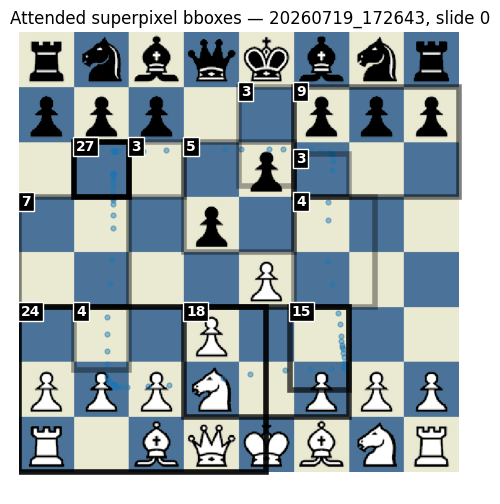

Gaze evaluation for displayed slide


,set_name,slide_index,bbox_count,attended_bboxes,attended_bbox_ratio,total_gaze_points,bbox_hit_count,unique_gaze_hit_count,coverage_by_bboxes,overlap_factor,max_attention_score,mean_attention_score
0,20260719_172643,0,34,12,0.352941,95,122,95,1.0,1.284211,0.284211,0.037771


Fixation evaluation for displayed slide


,set_name,slide_index,bbox_count,attended_bboxes,attended_bbox_ratio,total_gaze_points,bbox_hit_count,unique_gaze_hit_count,coverage_by_bboxes,overlap_factor,max_attention_score,mean_attention_score
0,20260719_172643,0,34,6,0.176471,6,8,6,1.0,1.333333,0.333333,0.039216


,set_name,slide_index,total_gaze_points,bbox_hit_count,unique_gaze_hit_count,coverage_by_bboxes,overlap_factor
0,20260719_172643,0,95,122,95,1.0,1.284211
1,20260719_172643,1,99,130,99,1.0,1.313131
2,20260719_172643,2,95,125,95,1.0,1.315789
3,20260719_172643,3,98,124,98,1.0,1.265306
4,20260719_172643,4,198,234,198,1.0,1.181818
5,20260719_172643,5,89,100,89,1.0,1.123596
6,20260719_172643,6,214,340,214,1.0,1.588785
7,20260719_172643,7,69,72,69,1.0,1.043478
8,20260719_172643,8,92,117,92,1.0,1.271739
9,20260719_172643,9,61,100,61,1.0,1.639344


In [113]:
from pathlib import Path
import pandas as pd

print("▶ Loading data for bbox analysis")

# ============================================================
# 1. Load raw image rows and flattened gaze samples
# ============================================================

raw_sets = loader.get_all_data(flatten=False)
gaze_sets = loader.get_all_data(flatten=True)

non_empty_gaze_sets = {
    set_name: frame
    for set_name, frame in gaze_sets.items()
    if frame is not None and not frame.empty
}

if not non_empty_gaze_sets:
    raise ValueError("No experiment run contains gaze samples.")

raw_data = pd.concat(
    raw_sets.values(),
    keys=raw_sets.keys(),
    names=["set_name", "row_index"],
).reset_index(level="set_name").reset_index(drop=True)

# Zero-based slide index inside each experiment run.
raw_data["slide_index"] = (
    raw_data
    .groupby("set_name")
    .cumcount()
)

gaze_data = pd.concat(
    non_empty_gaze_sets.values(),
    ignore_index=True,
)

# ============================================================
# 2. Normalize identifiers
# ============================================================

raw_data["set_name"] = raw_data["set_name"].astype(str)
gaze_data["set_name"] = gaze_data["set_name"].astype(str)

raw_data["slide_index"] = pd.to_numeric(
    raw_data["slide_index"],
    errors="coerce",
).astype("Int64")

gaze_data["slide_index"] = pd.to_numeric(
    gaze_data["slide_index"],
    errors="coerce",
).astype("Int64")

# ============================================================
# 3. Remove experiment runs without gaze
# ============================================================

sets_with_gaze = (
    gaze_data["set_name"]
    .dropna()
    .unique()
    .tolist()
)

raw_data = raw_data[
    raw_data["set_name"].isin(sets_with_gaze)
].copy()

gaze_data = gaze_data[
    gaze_data["set_name"].isin(sets_with_gaze)
].copy()

if raw_data.empty:
    raise ValueError(
        "No raw image rows match the experiment runs containing gaze."
    )

print("Experiment sets used:", sets_with_gaze)
print("Raw image rows:", len(raw_data))
print("Gaze samples:", len(gaze_data))

display(raw_data.head())
display(gaze_data.head())

# ============================================================
# 4. Generate bbox/gaze scores
# ============================================================

output_dir = Path("./analysis_outputs")
output_dir.mkdir(parents=True, exist_ok=True)

bbox_analyzer = BBoxAttentionAnalyzer(
    output_folder=output_dir
)

print("▶ Mapping gaze points to generated bboxes")

bbox_scores = bbox_analyzer.analyze(
    raw_data=raw_data,
    gaze_data=gaze_data,
    use_fixations=False,
)

if bbox_scores.empty:
    raise ValueError(
        "No bbox scores were generated. "
        "Check the objects_bboxes column in data.csv."
    )

print("Generated bbox score rows:", len(bbox_scores))
display(bbox_scores.head())

# ============================================================
# 5. Evaluate bbox/gaze mapping
# ============================================================

print("▶ Evaluating bbox/gaze mapping quality")

bbox_eval = bbox_analyzer.evaluate(
    bbox_scores
)

bbox_eval_with_gaze = bbox_eval[
    bbox_eval["total_gaze_points"] > 0
].copy()

assert bbox_eval["coverage_by_bboxes"].between(0, 1).all()

display(
    bbox_eval_with_gaze.sort_values(
        [
            "coverage_by_bboxes",
            "max_attention_score",
        ],
        ascending=False,
    )
)

# ============================================================
# 6. Select the same slide as the other analyzers
# ============================================================

selected_background = background_data[
    background_data["set_name"].astype(str).isin(
        sets_with_gaze
    )
].copy()

if selected_background.empty:
    raise ValueError(
        "background_data does not contain a run with gaze."
    )

# Same convention as heatmap, fixation and saccade examples.
selected_slide = selected_background.iloc[0]

set_name = str(selected_slide["set_name"])
slide_index = int(selected_slide["slide_index"])

matching_raw_rows = raw_data[
    (raw_data["set_name"] == set_name)
    & (
        raw_data["slide_index"]
        == slide_index
    )
]

if len(matching_raw_rows) != 1:
    raise ValueError(
        f"Expected one raw image row for "
        f"set={set_name}, slide={slide_index}; "
        f"found {len(matching_raw_rows)}."
    )

example_slide = matching_raw_rows.iloc[0]

screenshot_path = (
    Path(loader.root)
    / example_slide["screenshot_file"]
)

if not screenshot_path.exists():
    raise FileNotFoundError(
        f"Screenshot not found: {screenshot_path}"
    )

print("Selected set:", set_name)
print("Selected slide:", slide_index)
print("Screenshot:", screenshot_path)

# ============================================================
# 7. Plot attended superpixel bboxes
# ============================================================

print("▶ Visualizing attended bboxes on screenshot")

bbox_analyzer.plot_analysis(
    scored_bboxes=bbox_scores,
    gaze_data=gaze_data,
    screenshot_path=screenshot_path,
    set_name=set_name,
    slide_index=slide_index,
    top_k=25,
    min_hits=1,
    title=(
        f"Attended superpixel bboxes — "
        f"{set_name}, slide {slide_index}"
    ),
    save_path=(
        output_dir
        / f"bbox_attention_{set_name}_slide_{slide_index}.png"
    ),
)

# ============================================================
# 8. Map fixations to the same bboxes
# ============================================================

fixations = fixation_analyzer.analyze(
    background_data
)

bbox_fixation_scores = bbox_analyzer.analyze(
    raw_data=raw_data,
    gaze_data=fixations,
    use_fixations=True,
)

bbox_fixation_eval = bbox_analyzer.evaluate(
    bbox_fixation_scores
)

# ============================================================
# 9. Show evaluation only for the displayed slide
# ============================================================

print("Gaze evaluation for displayed slide")

selected_gaze_eval = bbox_eval[
    (bbox_eval["set_name"].astype(str) == set_name)
    & (
        pd.to_numeric(
            bbox_eval["slide_index"],
            errors="coerce",
        ) == slide_index
    )
]

display(selected_gaze_eval)

print("Fixation evaluation for displayed slide")

selected_fixation_eval = bbox_fixation_eval[
    (
        bbox_fixation_eval["set_name"].astype(str)
        == set_name
    )
    & (
        pd.to_numeric(
            bbox_fixation_eval["slide_index"],
            errors="coerce",
        ) == slide_index
    )
]

display(selected_fixation_eval)

# ============================================================
# 10. Validation table
# ============================================================

display(
    bbox_eval_with_gaze[
        [
            "set_name",
            "slide_index",
            "total_gaze_points",
            "bbox_hit_count",
            "unique_gaze_hit_count",
            "coverage_by_bboxes",
            "overlap_factor",
        ]
    ].sort_values(
        ["set_name", "slide_index"]
    )
)

▶ Creating ImageDataset
Detector: superpixel
Loaded images: 65
Selected image: /Users/dima/tobii/tobii-pytracker/datasets/chess/good/frame_35_delay-1s.gif
Image class: chess
Generated bboxes: 37


,bbox_index,class,confidence,cx,cy,w,h,has_required_keys,finite_values,positive_size,inside_aoi
0,0,superpixel,1.0,-234.37500,282.81250,281.2500,184.3750,True,True,True,True
1,1,superpixel,1.0,-91.40625,280.46875,192.1875,189.0625,True,True,True,True
2,2,superpixel,1.0,140.62500,281.25000,281.2500,187.5000,True,True,True,True
3,3,superpixel,1.0,328.12500,328.12500,93.7500,93.7500,True,True,True,True
4,4,superpixel,1.0,-328.12500,187.50000,93.7500,187.5000,True,True,True,True
5,5,superpixel,1.0,-181.25000,187.50000,200.0000,187.5000,True,True,True,True
6,6,superpixel,1.0,328.12500,187.50000,93.7500,187.5000,True,True,True,True
7,7,superpixel,1.0,-42.96875,109.37500,101.5625,156.2500,True,True,True,True
8,8,superpixel,1.0,49.21875,140.62500,89.0625,93.7500,True,True,True,True
9,9,superpixel,1.0,187.50000,109.37500,187.5000,156.2500,True,True,True,True


✓ Bbox structure validation passed
AOI size: (750, 750)

Total bboxes: 37
Overlapping bbox pairs: 25
Nested bbox pairs: 2
Overlapping pairs:


,bbox_a,bbox_b,intersection_area
0,0,1,17285.156250
1,0,4,8496.093750
2,0,5,16992.187500
3,1,2,878.906250
4,1,5,10126.953125
5,1,7,153.808594
6,5,7,1171.875000
7,7,8,292.968750
8,7,13,6347.656250
9,9,14,11718.750000


Nested pairs:


,inner_bbox,outer_bbox
0,30,29
1,31,29


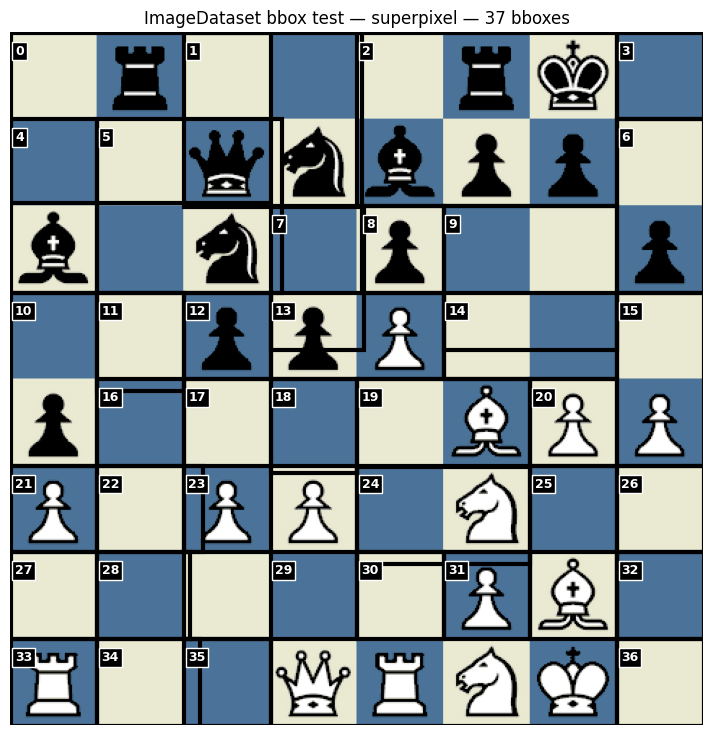

✓ ImageDataset bbox test completed
Saved visualization: analysis_outputs/imagedataset_bbox_test_superpixel.png


In [114]:
# ============================================================
# ImageDataset bbox-generation test
# ============================================================

from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import pandas as pd
from PIL import Image

from tobii_pytracker.datasets.custom_dataset import ImageDataset


# ------------------------------------------------------------
# 1. Create ImageDataset with bbox generation enabled
# ------------------------------------------------------------

TEST_SAMPLE_INDEX = 0

output_dir = Path("./analysis_outputs")
output_dir.mkdir(parents=True, exist_ok=True)

print("▶ Creating ImageDataset")

image_dataset = ImageDataset(
    config=config,
    calculate_bboxes=True,
)

if not image_dataset.data:
    raise ValueError(
        "ImageDataset did not load any images. "
        "Check the image dataset path in the configuration."
    )

if not 0 <= TEST_SAMPLE_INDEX < len(image_dataset.data):
    raise IndexError(
        f"TEST_SAMPLE_INDEX={TEST_SAMPLE_INDEX} is invalid. "
        f"Available range: 0 to {len(image_dataset.data) - 1}."
    )


# ------------------------------------------------------------
# 2. Select one image and its generated bboxes
# ------------------------------------------------------------

test_sample = image_dataset.data[TEST_SAMPLE_INDEX]

image_path = Path(test_sample["data"])
generated_bboxes = test_sample.get("bboxes", [])

if not image_path.exists():
    raise FileNotFoundError(
        f"Image file does not exist: {image_path}"
    )

if not generated_bboxes:
    raise ValueError(
        "ImageDataset did not generate any bboxes. "
        "Check calculate_bboxes=True and bbox_model in the config."
    )

detector_name = (
    image_dataset.model.__class__.__name__
    if image_dataset.model is not None
    else image_dataset.default_detector
)

print("Detector:", detector_name)
print("Loaded images:", len(image_dataset.data))
print("Selected image:", image_path)
print("Image class:", test_sample.get("class"))
print("Generated bboxes:", len(generated_bboxes))


# ------------------------------------------------------------
# 3. Validate bbox structure and coordinates
# ------------------------------------------------------------

area_x, area_y = config.get_area_of_interest_size()

validation_rows = []

for bbox_index, record in enumerate(generated_bboxes):
    bbox = record.get("bbox", {})

    required_keys = {"cx", "cy", "w", "h"}
    has_required_keys = required_keys.issubset(bbox)

    if has_required_keys:
        cx = float(bbox["cx"])
        cy = float(bbox["cy"])
        width = float(bbox["w"])
        height = float(bbox["h"])

        x_min = cx - width / 2.0
        x_max = cx + width / 2.0
        y_min = cy - height / 2.0
        y_max = cy + height / 2.0

        finite_values = np.isfinite(
            [cx, cy, width, height]
        ).all()

        positive_size = (
            width > 0
            and height > 0
        )

        inside_aoi = (
            x_min >= -area_x / 2.0 - 1e-6
            and x_max <= area_x / 2.0 + 1e-6
            and y_min >= -area_y / 2.0 - 1e-6
            and y_max <= area_y / 2.0 + 1e-6
        )

    else:
        cx = np.nan
        cy = np.nan
        width = np.nan
        height = np.nan
        finite_values = False
        positive_size = False
        inside_aoi = False

    validation_rows.append({
        "bbox_index": bbox_index,
        "class": record.get("class"),
        "confidence": record.get("conf"),
        "cx": cx,
        "cy": cy,
        "w": width,
        "h": height,
        "has_required_keys": has_required_keys,
        "finite_values": finite_values,
        "positive_size": positive_size,
        "inside_aoi": inside_aoi,
    })

bbox_validation = pd.DataFrame(validation_rows)

display(bbox_validation)

assert bbox_validation["has_required_keys"].all(), (
    "Some bboxes do not contain cx, cy, w and h."
)

assert bbox_validation["finite_values"].all(), (
    "Some bbox coordinates contain NaN or infinite values."
)

assert bbox_validation["positive_size"].all(), (
    "Some bboxes have zero or negative width or height."
)

assert bbox_validation["inside_aoi"].all(), (
    "Some bboxes extend outside the configured AOI."
)

print("✓ Bbox structure validation passed")
print("AOI size:", (area_x, area_y))


# ------------------------------------------------------------
# 4. Detect overlapping and nested bboxes
# ------------------------------------------------------------

def bbox_edges(record):
    bbox = record["bbox"]

    cx = float(bbox["cx"])
    cy = float(bbox["cy"])
    width = float(bbox["w"])
    height = float(bbox["h"])

    return {
        "x_min": cx - width / 2.0,
        "x_max": cx + width / 2.0,
        "y_min": cy - height / 2.0,
        "y_max": cy + height / 2.0,
    }


def calculate_intersection_area(first, second):
    intersection_width = max(
        0.0,
        min(first["x_max"], second["x_max"])
        - max(first["x_min"], second["x_min"]),
    )

    intersection_height = max(
        0.0,
        min(first["y_max"], second["y_max"])
        - max(first["y_min"], second["y_min"]),
    )

    return intersection_width * intersection_height


def bbox_is_inside(inner, outer):
    return (
        outer["x_min"] <= inner["x_min"]
        and inner["x_max"] <= outer["x_max"]
        and outer["y_min"] <= inner["y_min"]
        and inner["y_max"] <= outer["y_max"]
    )


bbox_edge_values = [
    bbox_edges(record)
    for record in generated_bboxes
]

overlap_rows = []
nested_rows = []

for first_index in range(len(bbox_edge_values)):
    for second_index in range(
        first_index + 1,
        len(bbox_edge_values),
    ):
        first_bbox = bbox_edge_values[first_index]
        second_bbox = bbox_edge_values[second_index]

        intersection_area = calculate_intersection_area(
            first_bbox,
            second_bbox,
        )

        if intersection_area > 0:
            overlap_rows.append({
                "bbox_a": first_index,
                "bbox_b": second_index,
                "intersection_area": intersection_area,
            })

        if bbox_is_inside(first_bbox, second_bbox):
            nested_rows.append({
                "inner_bbox": first_index,
                "outer_bbox": second_index,
            })

        elif bbox_is_inside(second_bbox, first_bbox):
            nested_rows.append({
                "inner_bbox": second_index,
                "outer_bbox": first_index,
            })

overlap_table = pd.DataFrame(overlap_rows)
nested_table = pd.DataFrame(nested_rows)

print()
print("Total bboxes:", len(generated_bboxes))
print("Overlapping bbox pairs:", len(overlap_table))
print("Nested bbox pairs:", len(nested_table))

if not overlap_table.empty:
    print("Overlapping pairs:")
    display(overlap_table)

if not nested_table.empty:
    print("Nested pairs:")
    display(nested_table)


# ------------------------------------------------------------
# 5. Draw generated bboxes on the original image
# ------------------------------------------------------------

with Image.open(image_path) as pil_image:
    pil_image.seek(0)
    image = np.asarray(
        pil_image.convert("RGB")
    )

image_height, image_width = image.shape[:2]

scale_x = image_width / float(area_x)
scale_y = image_height / float(area_y)

fig, ax = plt.subplots(figsize=(14, 9))

ax.imshow(
    image,
    origin="upper",
)

for bbox_index, record in enumerate(generated_bboxes):
    bbox = record["bbox"]

    cx = float(bbox["cx"])
    cy = float(bbox["cy"])
    bbox_width = float(bbox["w"])
    bbox_height = float(bbox["h"])

    # Convert centered AOI coordinates to top-left AOI coordinates.
    x_min_aoi = (
        area_x / 2.0
        + cx
        - bbox_width / 2.0
    )

    y_min_aoi = (
        area_y / 2.0
        - cy
        - bbox_height / 2.0
    )

    # Convert AOI coordinates to original image coordinates.
    x_min_image = x_min_aoi * scale_x
    y_min_image = y_min_aoi * scale_y

    bbox_width_image = bbox_width * scale_x
    bbox_height_image = bbox_height * scale_y

    rectangle = patches.Rectangle(
        (x_min_image, y_min_image),
        bbox_width_image,
        bbox_height_image,
        linewidth=3.0,
        edgecolor="black",
        facecolor="none",
        alpha=1.0,
        zorder=10,
    )

    ax.add_patch(rectangle)

    # The label is the bbox index, not a gaze-hit count.
    ax.text(
        x_min_image + 3,
        y_min_image + 15,
        str(bbox_index),
        color="white",
        fontsize=9,
        fontweight="bold",
        zorder=11,
        bbox={
            "facecolor": "black",
            "edgecolor": "white",
            "alpha": 1.0,
            "pad": 2,
        },
    )

ax.set_title(
    f"ImageDataset bbox test — "
    f"{detector_name} — "
    f"{len(generated_bboxes)} bboxes"
)

ax.axis("off")

output_path = (
    output_dir
    / f"imagedataset_bbox_test_{detector_name}.png"
)

fig.savefig(
    output_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print("✓ ImageDataset bbox test completed")
print("Saved visualization:", output_path)

▶ Loading experiment data
Experiment runs with gaze: ['20260719_172643']
Raw trial rows: 10
Gaze samples: 1110

Selected experiment run: 20260719_172643
Selected slide: 0
Original image: /Users/dima/tobii/tobii-pytracker/datasets/chess/good/frame_05_delay-1s.gif
Experiment screenshot: /Users/dima/tobii/tobii-pytracker/output/20260719_172643/frame_05_delay-1s.gif
Gaze samples: 95
Bboxes stored in data.csv: 34

▶ Testing ImageDataset automatic bbox generation
Configured ImageDataset bboxes: 34

▶ Generating superpixel and grid bboxes
Saliency method skipped: 'NoneType' object has no attribute 'shape'
superpixel: 34 generated bboxes
grid: 9 generated bboxes

▶ Validating generated bboxes


,method,bbox_count,all_bboxes_valid,overlap_pairs,nested_pairs
0,superpixel,34,True,30,10
1,grid,9,True,0,0


,method,bbox_index,class,cx,cy,w,h,has_required_keys,finite_values,positive_size,inside_aoi
0,superpixel,0,superpixel,0.00000,281.25000,750.0000,187.5000,True,True,True,True
1,superpixel,1,superpixel,-187.50000,234.37500,187.5000,93.7500,True,True,True,True
2,superpixel,2,superpixel,-45.31250,234.37500,146.8750,93.7500,True,True,True,True
3,superpixel,3,superpixel,46.87500,196.87500,93.7500,168.7500,True,True,True,True
4,superpixel,4,superpixel,234.37500,187.50000,281.2500,187.5000,True,True,True,True
5,superpixel,5,superpixel,328.12500,204.68750,93.7500,153.1250,True,True,True,True
6,superpixel,6,superpixel,-328.12500,140.62500,93.7500,93.7500,True,True,True,True
7,superpixel,7,superpixel,-234.37500,140.62500,93.7500,93.7500,True,True,True,True
8,superpixel,8,superpixel,-140.62500,140.62500,93.7500,93.7500,True,True,True,True
9,superpixel,9,superpixel,0.00000,93.75000,187.5000,187.5000,True,True,True,True



▶ Mapping gaze to generated bboxes


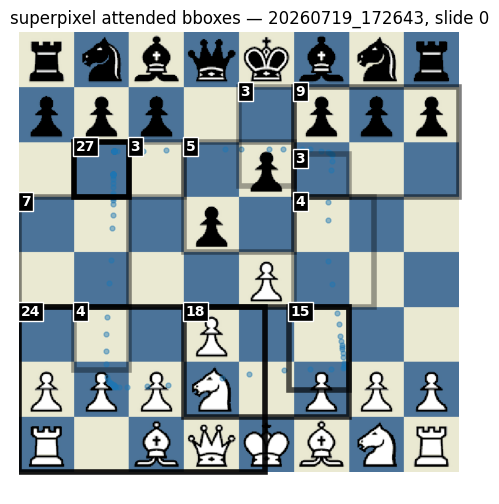

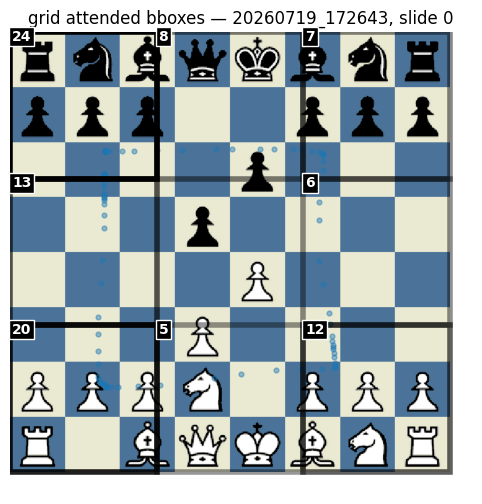


▶ Bbox method comparison


,method,generated_bbox_count,total_gaze_points,bbox_hit_count,unique_gaze_hit_count,coverage_by_bboxes,overlap_factor,attended_bboxes,attended_bbox_ratio,max_attention_score,mean_attention_score
1,grid,9,95,95,95,1.0,1.000000,8,0.888889,0.252632,0.111111
0,superpixel,34,95,122,95,1.0,1.284211,12,0.352941,0.284211,0.037771



▶ Definition of Done


,requirement,status
0,Normal ImageDataset automatic generation works,PASS
1,Superpixel bbox generation works,PASS
2,At least one other method works,PASS
3,All generated bbox coordinates are valid,PASS
4,The selected experiment trial contains gaze,PASS
5,The trial contains bboxes saved in data.csv,PASS
6,Superpixel and grid were mapped to gaze,PASS
7,Unique gaze coverage stays between 0 and 1,PASS
8,The exact experiment screenshot exists,PASS
9,Attention plots were saved,PASS



DEFINITION OF DONE: PASS — task completed

Saved attention plots:
superpixel: analysis_outputs/bbox_task_test/20260719_172643_slide_0_superpixel_attention.png
grid: analysis_outputs/bbox_task_test/20260719_172643_slide_0_grid_attention.png


In [115]:
# ============================================================
# COMPLETE IMAGE BBOX TASK TEST
#
# Tests:
# 1. ImageDataset generates bboxes.
# 2. Superpixel and grid methods work.
# 3. Generated bbox coordinates are valid.
# 4. Gaze from data.csv maps to generated bboxes.
# 5. Attended bboxes are drawn on the exact experiment screenshot.
# 6. A final Definition of Done table reports PASS or FAIL.
# ============================================================

from pathlib import Path
import ast

import numpy as np
import pandas as pd
from IPython.display import display

from tobii_pytracker.datasets.custom_dataset import ImageDataset
from tobii_pytracker.analyze.models import BBoxAttentionAnalyzer


# ============================================================
# 1. Configuration
# ============================================================

OUTPUT_DIR = Path("./analysis_outputs/bbox_task_test")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Leave both as None to select the first slide containing gaze.
# To select a specific slide, provide both values.
SELECTED_SET_NAME = None
SELECTED_SLIDE_INDEX = None


# ============================================================
# 2. Helper functions
# ============================================================

def parse_bbox_container(value):
    """
    Convert the objects_bboxes value from data.csv into a dictionary.
    """

    if isinstance(value, dict):
        return value

    if isinstance(value, str):
        value = value.strip()

        if not value:
            return {}

        try:
            parsed = ast.literal_eval(value)
            return parsed if isinstance(parsed, dict) else {}
        except (ValueError, SyntaxError):
            return {}

    return {}


def extract_image_bboxes(value):
    """
    Extract image_bboxes from objects_bboxes.
    """

    container = parse_bbox_container(value)
    bboxes = container.get("image_bboxes", [])

    return bboxes if isinstance(bboxes, list) else []


def resolve_file_path(value):
    """
    Resolve an absolute or project-relative file path.
    """

    path = Path(str(value))

    if path.is_absolute():
        return path

    possible_paths = [
        Path(loader.root) / path,
        Path.cwd() / path,
    ]

    for possible_path in possible_paths:
        if possible_path.exists():
            return possible_path.resolve()

    return (Path(loader.root) / path).resolve()


def bbox_edges(record):
    """
    Convert cx, cy, w, h to rectangle edges.
    """

    bbox = record["bbox"]

    cx = float(bbox["cx"])
    cy = float(bbox["cy"])
    width = float(bbox["w"])
    height = float(bbox["h"])

    return {
        "x_min": cx - width / 2.0,
        "x_max": cx + width / 2.0,
        "y_min": cy - height / 2.0,
        "y_max": cy + height / 2.0,
    }


def intersection_area(first, second):
    """
    Calculate the overlapping area of two bboxes.
    """

    overlap_width = max(
        0.0,
        min(first["x_max"], second["x_max"])
        - max(first["x_min"], second["x_min"]),
    )

    overlap_height = max(
        0.0,
        min(first["y_max"], second["y_max"])
        - max(first["y_min"], second["y_min"]),
    )

    return overlap_width * overlap_height


def is_inside(inner, outer):
    """
    Check whether one bbox is fully inside another bbox.
    """

    return (
        outer["x_min"] <= inner["x_min"]
        and inner["x_max"] <= outer["x_max"]
        and outer["y_min"] <= inner["y_min"]
        and inner["y_max"] <= outer["y_max"]
    )


# ============================================================
# 3. Load experiment data and gaze from data.csv
# ============================================================

print("▶ Loading experiment data")

raw_sets = loader.get_all_data(flatten=False)
gaze_sets = loader.get_all_data(flatten=True)

if not raw_sets:
    raise ValueError("No raw experiment data was found.")

non_empty_gaze_sets = {
    set_name: frame
    for set_name, frame in gaze_sets.items()
    if frame is not None and not frame.empty
}

if not non_empty_gaze_sets:
    raise ValueError("No experiment run contains gaze samples.")


raw_data = pd.concat(
    raw_sets.values(),
    keys=raw_sets.keys(),
    names=["set_name", "row_index"],
).reset_index(level="set_name").reset_index(drop=True)


# Zero-based slide index inside every experiment run.
raw_data["slide_index"] = (
    raw_data
    .groupby("set_name")
    .cumcount()
)


gaze_data = pd.concat(
    non_empty_gaze_sets.values(),
    ignore_index=True,
)


# Normalize identifiers.
raw_data["set_name"] = raw_data["set_name"].astype(str)
gaze_data["set_name"] = gaze_data["set_name"].astype(str)

raw_data["slide_index"] = pd.to_numeric(
    raw_data["slide_index"],
    errors="coerce",
).astype("Int64")

gaze_data["slide_index"] = pd.to_numeric(
    gaze_data["slide_index"],
    errors="coerce",
).astype("Int64")


# Remove experiment runs without gaze.
sets_with_gaze = set(
    gaze_data["set_name"]
    .dropna()
    .unique()
)

raw_data = raw_data[
    raw_data["set_name"].isin(sets_with_gaze)
].copy()

gaze_data = gaze_data[
    gaze_data["set_name"].isin(sets_with_gaze)
].copy()


print("Experiment runs with gaze:", sorted(sets_with_gaze))
print("Raw trial rows:", len(raw_data))
print("Gaze samples:", len(gaze_data))


# ============================================================
# 4. Select one real experiment slide
# ============================================================

gaze_counts = (
    gaze_data
    .groupby(["set_name", "slide_index"])
    .size()
    .rename("gaze_count")
    .reset_index()
)

trial_candidates = raw_data.merge(
    gaze_counts,
    on=["set_name", "slide_index"],
    how="inner",
)

trial_candidates = trial_candidates[
    trial_candidates["gaze_count"] > 0
].copy()


if (
    SELECTED_SET_NAME is not None
    or SELECTED_SLIDE_INDEX is not None
):
    if (
        SELECTED_SET_NAME is None
        or SELECTED_SLIDE_INDEX is None
    ):
        raise ValueError(
            "Set both SELECTED_SET_NAME and "
            "SELECTED_SLIDE_INDEX, or leave both as None."
        )

    selected_rows = trial_candidates[
        (
            trial_candidates["set_name"]
            == str(SELECTED_SET_NAME)
        )
        & (
            trial_candidates["slide_index"]
            == int(SELECTED_SLIDE_INDEX)
        )
    ]

else:
    selected_rows = trial_candidates.head(1)


if selected_rows.empty:
    raise ValueError(
        "No matching experiment slide with gaze was found."
    )


selected_raw = selected_rows.iloc[0].copy()

set_name = str(selected_raw["set_name"])
slide_index = int(selected_raw["slide_index"])


selected_gaze = gaze_data[
    (gaze_data["set_name"] == set_name)
    & (
        gaze_data["slide_index"]
        == slide_index
    )
].copy()


input_image_path = resolve_file_path(
    selected_raw["input_data"]
)

screenshot_path = resolve_file_path(
    selected_raw["screenshot_file"]
)


if not input_image_path.exists():
    raise FileNotFoundError(
        f"Original input image not found: {input_image_path}"
    )

if not screenshot_path.exists():
    raise FileNotFoundError(
        f"Experiment screenshot not found: {screenshot_path}"
    )


stored_trial_bboxes = extract_image_bboxes(
    selected_raw.get("objects_bboxes")
)


print()
print("Selected experiment run:", set_name)
print("Selected slide:", slide_index)
print("Original image:", input_image_path)
print("Experiment screenshot:", screenshot_path)
print("Gaze samples:", len(selected_gaze))
print("Bboxes stored in data.csv:", len(stored_trial_bboxes))


# ============================================================
# 5. Test normal ImageDataset bbox generation
# ============================================================

print()
print("▶ Testing ImageDataset automatic bbox generation")

configured_generation_error = None
configured_bboxes = []

try:
    configured_dataset = ImageDataset(
        config=config,
        calculate_bboxes=True,
    )

    selected_dataset_sample = None

    for sample in configured_dataset.data:
        sample_path = Path(sample["data"]).resolve()

        if sample_path == input_image_path.resolve():
            selected_dataset_sample = sample
            break

    if selected_dataset_sample is not None:
        configured_bboxes = selected_dataset_sample.get(
            "bboxes",
            [],
        )
    else:
        configured_generation_error = (
            "The selected experiment image was not found "
            "inside ImageDataset.data."
        )

except Exception as exc:
    configured_generation_error = str(exc)


print(
    "Configured ImageDataset bboxes:",
    len(configured_bboxes),
)

if configured_generation_error:
    print(
        "Configured ImageDataset warning:",
        configured_generation_error,
    )


# ============================================================
# 6. Generate bboxes with superpixel and grid methods
# ============================================================

print()
print("▶ Generating superpixel and grid bboxes")

method_dataset = ImageDataset(
    config=config,
    calculate_bboxes=False,
)


superpixel_bboxes = method_dataset._detect_superpixels(
    str(input_image_path)
)

grid_bboxes = method_dataset._detect_grid(
    str(input_image_path)
)


generated_by_method = {
    "superpixel": superpixel_bboxes,
    "grid": grid_bboxes,
}


# Saliency is optional because it requires OpenCV saliency support.
try:
    saliency_bboxes = method_dataset._detect_saliency(
        str(input_image_path)
    )

    if saliency_bboxes:
        generated_by_method["saliency"] = saliency_bboxes

except Exception as exc:
    print("Saliency method skipped:", exc)


for method_name, method_bboxes in generated_by_method.items():
    print(
        f"{method_name}: {len(method_bboxes)} generated bboxes"
    )


# ============================================================
# 7. Validate generated bbox coordinates
# ============================================================

print()
print("▶ Validating generated bboxes")

area_x, area_y = config.get_area_of_interest_size()

validation_rows = []
method_summary_rows = []


for method_name, method_bboxes in generated_by_method.items():
    method_valid_rows = []

    for bbox_index, record in enumerate(method_bboxes):
        bbox = record.get("bbox", {})

        required_keys = {"cx", "cy", "w", "h"}

        has_required_keys = required_keys.issubset(
            bbox
        )

        if has_required_keys:
            cx = float(bbox["cx"])
            cy = float(bbox["cy"])
            width = float(bbox["w"])
            height = float(bbox["h"])

            x_min = cx - width / 2.0
            x_max = cx + width / 2.0
            y_min = cy - height / 2.0
            y_max = cy + height / 2.0

            finite_values = np.isfinite(
                [cx, cy, width, height]
            ).all()

            positive_size = (
                width > 0
                and height > 0
            )

            inside_aoi = (
                x_min >= -area_x / 2.0 - 1e-6
                and x_max <= area_x / 2.0 + 1e-6
                and y_min >= -area_y / 2.0 - 1e-6
                and y_max <= area_y / 2.0 + 1e-6
            )

        else:
            cx = np.nan
            cy = np.nan
            width = np.nan
            height = np.nan
            finite_values = False
            positive_size = False
            inside_aoi = False

        row_valid = (
            has_required_keys
            and finite_values
            and positive_size
            and inside_aoi
        )

        method_valid_rows.append(row_valid)

        validation_rows.append({
            "method": method_name,
            "bbox_index": bbox_index,
            "class": record.get("class"),
            "cx": cx,
            "cy": cy,
            "w": width,
            "h": height,
            "has_required_keys": has_required_keys,
            "finite_values": finite_values,
            "positive_size": positive_size,
            "inside_aoi": inside_aoi,
        })


    # Count overlapping and nested bbox pairs.
    edges = [
        bbox_edges(record)
        for record in method_bboxes
    ]

    overlap_pairs = 0
    nested_pairs = 0

    for first_index in range(len(edges)):
        for second_index in range(
            first_index + 1,
            len(edges),
        ):
            first = edges[first_index]
            second = edges[second_index]

            if intersection_area(first, second) > 0:
                overlap_pairs += 1

            if (
                is_inside(first, second)
                or is_inside(second, first)
            ):
                nested_pairs += 1


    method_summary_rows.append({
        "method": method_name,
        "bbox_count": len(method_bboxes),
        "all_bboxes_valid": bool(
            method_valid_rows
            and all(method_valid_rows)
        ),
        "overlap_pairs": overlap_pairs,
        "nested_pairs": nested_pairs,
    })


bbox_validation = pd.DataFrame(validation_rows)
generation_summary = pd.DataFrame(method_summary_rows)

display(generation_summary)
display(bbox_validation.head(20))


# ============================================================
# 8. Map real gaze data to each generated bbox method
# ============================================================

print()
print("▶ Mapping gaze to generated bboxes")

bbox_analyzer = BBoxAttentionAnalyzer(
    output_folder=OUTPUT_DIR
)

scores_by_method = {}
evaluation_rows = {}
saved_plot_paths = {}


for method_name, method_bboxes in generated_by_method.items():
    # Create one temporary raw-data row for this method.
    method_raw_data = pd.DataFrame([
        selected_raw.to_dict()
    ])

    method_raw_data["set_name"] = (
        method_raw_data["set_name"]
        .astype(str)
    )

    method_raw_data["slide_index"] = pd.to_numeric(
        method_raw_data["slide_index"],
        errors="coerce",
    ).astype("Int64")


    # Replace the original stored boxes with boxes generated
    # by the currently tested method.
    method_raw_data.at[
        0,
        "objects_bboxes",
    ] = {
        "image_bboxes": method_bboxes
    }


    scores = bbox_analyzer.analyze(
        raw_data=method_raw_data,
        gaze_data=selected_gaze,
        use_fixations=False,
    )

    if scores.empty:
        raise ValueError(
            f"No bbox scores were generated for "
            f"method '{method_name}'."
        )


    evaluation = bbox_analyzer.evaluate(
        scores
    )

    if evaluation.empty:
        raise ValueError(
            f"No bbox evaluation was generated for "
            f"method '{method_name}'."
        )


    scores_by_method[method_name] = scores

    evaluation_row = evaluation.iloc[0].to_dict()
    evaluation_row["method"] = method_name
    evaluation_row["generated_bbox_count"] = len(
        method_bboxes
    )

    evaluation_rows[method_name] = evaluation_row


    # Draw the attended boxes on the exact screenshot
    # shown to the participant.
    plot_path = (
        OUTPUT_DIR
        / (
            f"{set_name}_slide_{slide_index}_"
            f"{method_name}_attention.png"
        )
    )

    bbox_analyzer.plot_analysis(
        scored_bboxes=scores,
        gaze_data=selected_gaze,
        screenshot_path=screenshot_path,
        set_name=set_name,
        slide_index=slide_index,
        top_k=25,
        min_hits=1,
        title=(
            f"{method_name} attended bboxes — "
            f"{set_name}, slide {slide_index}"
        ),
        save_path=plot_path,
    )

    saved_plot_paths[method_name] = plot_path


# ============================================================
# 9. Compare bbox methods
# ============================================================

comparison = pd.DataFrame(
    evaluation_rows.values()
)


preferred_columns = [
    "method",
    "generated_bbox_count",
    "total_gaze_points",
    "bbox_hit_count",
    "unique_gaze_hit_count",
    "coverage_by_bboxes",
    "overlap_factor",
    "attended_bboxes",
    "attended_bbox_ratio",
    "max_attention_score",
    "mean_attention_score",
]


available_columns = [
    column
    for column in preferred_columns
    if column in comparison.columns
]


print()
print("▶ Bbox method comparison")

display(
    comparison[
        available_columns
    ].sort_values(
        [
            column
            for column in [
                "coverage_by_bboxes",
                "overlap_factor",
            ]
            if column in comparison.columns
        ],
        ascending=[
            False,
            True,
        ][:len([
            column
            for column in [
                "coverage_by_bboxes",
                "overlap_factor",
            ]
            if column in comparison.columns
        ])],
    )
)


# ============================================================
# 10. Definition of Done
# ============================================================

required_methods = {
    "superpixel",
    "grid",
}

generated_methods = set(
    generated_by_method.keys()
)

evaluated_methods = set(
    comparison["method"]
)

required_plot_paths = [
    saved_plot_paths[method]
    for method in required_methods
    if method in saved_plot_paths
]


definition_of_done_rows = [
    {
        "requirement": (
            "Normal ImageDataset automatic generation works"
        ),
        "passed": len(configured_bboxes) > 0,
    },
    {
        "requirement": (
            "Superpixel bbox generation works"
        ),
        "passed": len(superpixel_bboxes) > 0,
    },
    {
        "requirement": (
            "At least one other method works"
        ),
        "passed": len(grid_bboxes) > 0,
    },
    {
        "requirement": (
            "All generated bbox coordinates are valid"
        ),
        "passed": bool(
            not generation_summary.empty
            and generation_summary[
                "all_bboxes_valid"
            ].all()
        ),
    },
    {
        "requirement": (
            "The selected experiment trial contains gaze"
        ),
        "passed": len(selected_gaze) > 0,
    },
    {
        "requirement": (
            "The trial contains bboxes saved in data.csv"
        ),
        "passed": len(stored_trial_bboxes) > 0,
    },
    {
        "requirement": (
            "Superpixel and grid were mapped to gaze"
        ),
        "passed": required_methods.issubset(
            evaluated_methods
        ),
    },
    {
        "requirement": (
            "Unique gaze coverage stays between 0 and 1"
        ),
        "passed": bool(
            comparison[
                "coverage_by_bboxes"
            ].between(0, 1).all()
        ),
    },
    {
        "requirement": (
            "The exact experiment screenshot exists"
        ),
        "passed": screenshot_path.exists(),
    },
    {
        "requirement": (
            "Attention plots were saved"
        ),
        "passed": (
            len(required_plot_paths)
            == len(required_methods)
            and all(
                path.exists()
                for path in required_plot_paths
            )
        ),
    },
    {
        "requirement": (
            "At least two bbox methods were compared"
        ),
        "passed": required_methods.issubset(
            generated_methods
        ),
    },
]


definition_of_done = pd.DataFrame(
    definition_of_done_rows
)

definition_of_done["status"] = np.where(
    definition_of_done["passed"],
    "PASS",
    "FAIL",
)


print()
print("▶ Definition of Done")

display(
    definition_of_done[
        [
            "requirement",
            "status",
        ]
    ]
)


all_checks_passed = bool(
    definition_of_done["passed"].all()
)


print()

if all_checks_passed:
    print(
        "DEFINITION OF DONE: PASS — task completed"
    )
else:
    print(
        "DEFINITION OF DONE: FAIL — "
        "review the failed checks above"
    )


print()
print("Saved attention plots:")

for method_name, plot_path in saved_plot_paths.items():
    print(
        f"{method_name}: {plot_path}"
    )